<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/

In [2]:
on_drive = False 
if on_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = ''
    output_path = ''
else:
    base_path = 'data-gesures/'
    output_path = 'scratch/'

## Setup Python Environment

In [3]:
#prints the path of the virtual environment
import sys
print(sys.executable)
# Setup environment
!pip install pandas numpy matplotlib seaborn
!pip install tensorflow


/Users/titien/Documents/ZZ2/S8/LOW-POWER-EMBEDDED-SYSTEMS/intro-tinyml/python-venv/env-arduino-3_11/env-3.11-fixed/bin/python3.11


# Graph of gestures

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

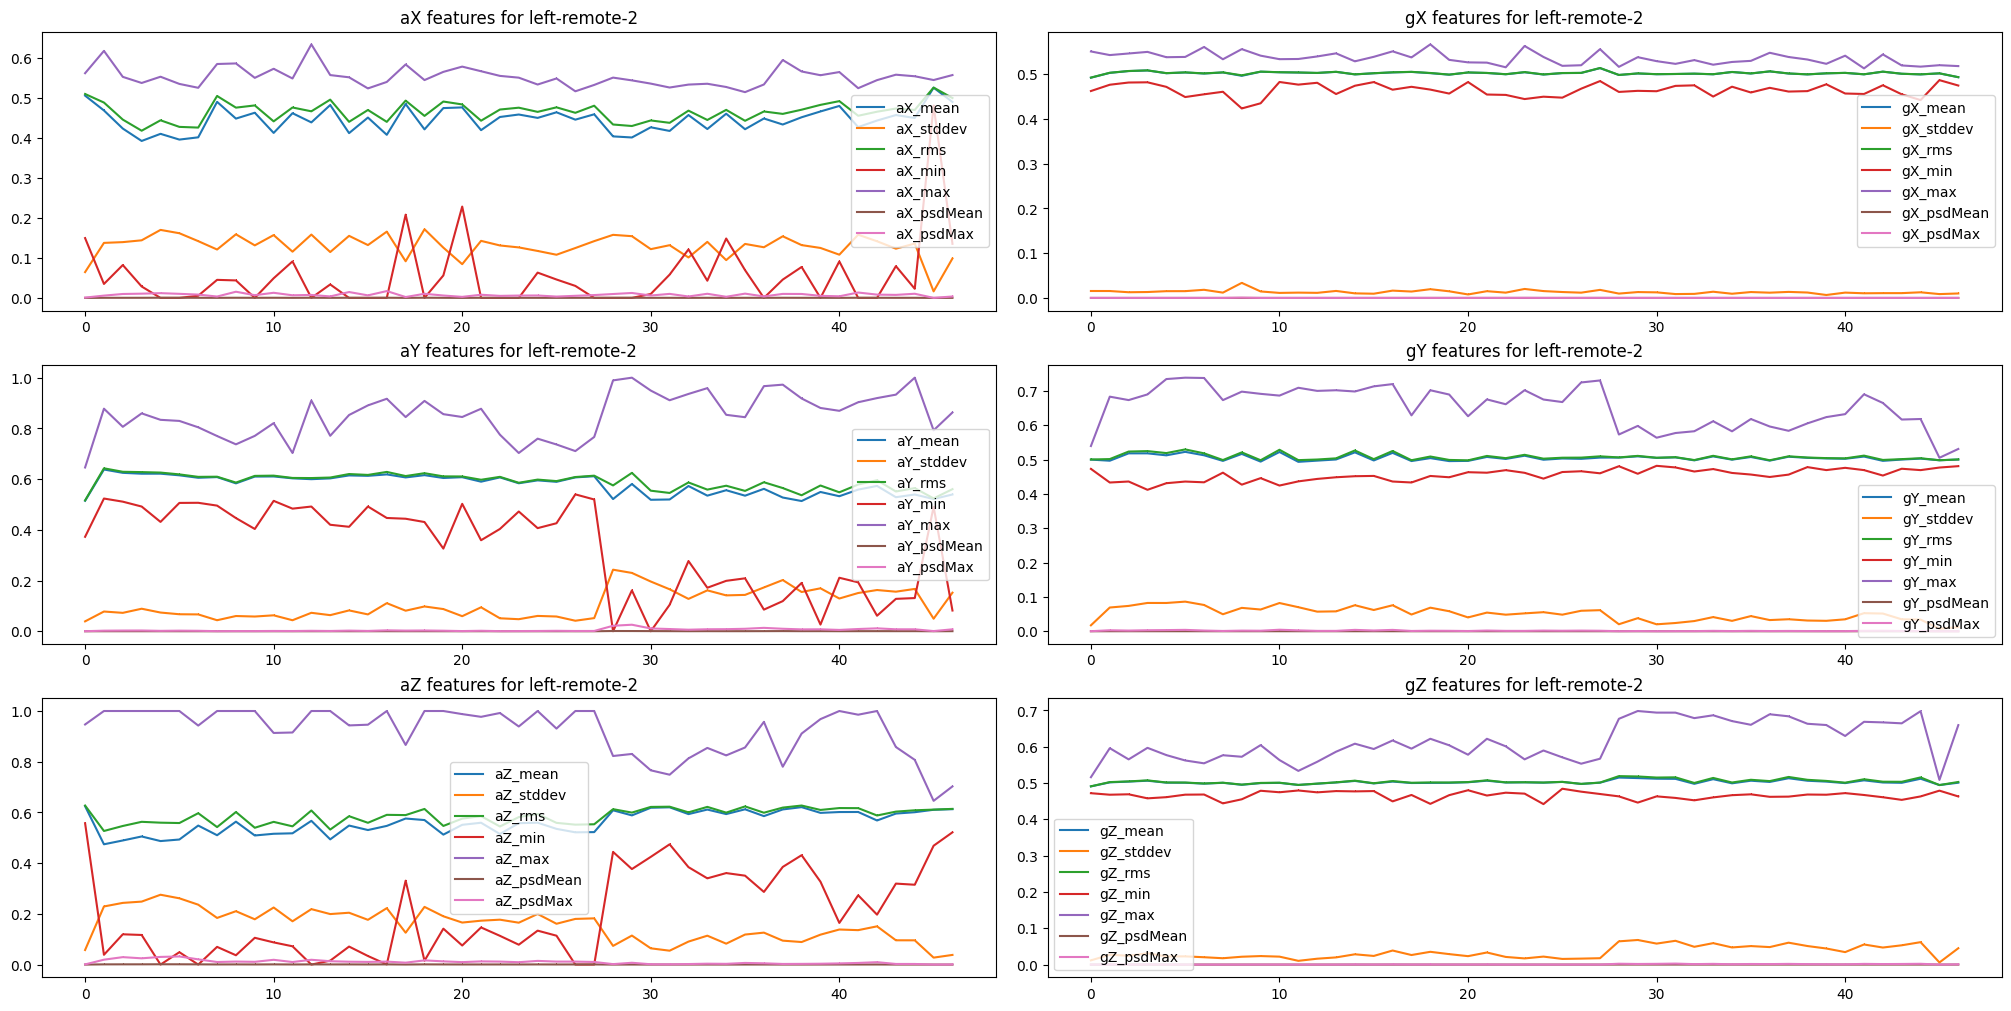

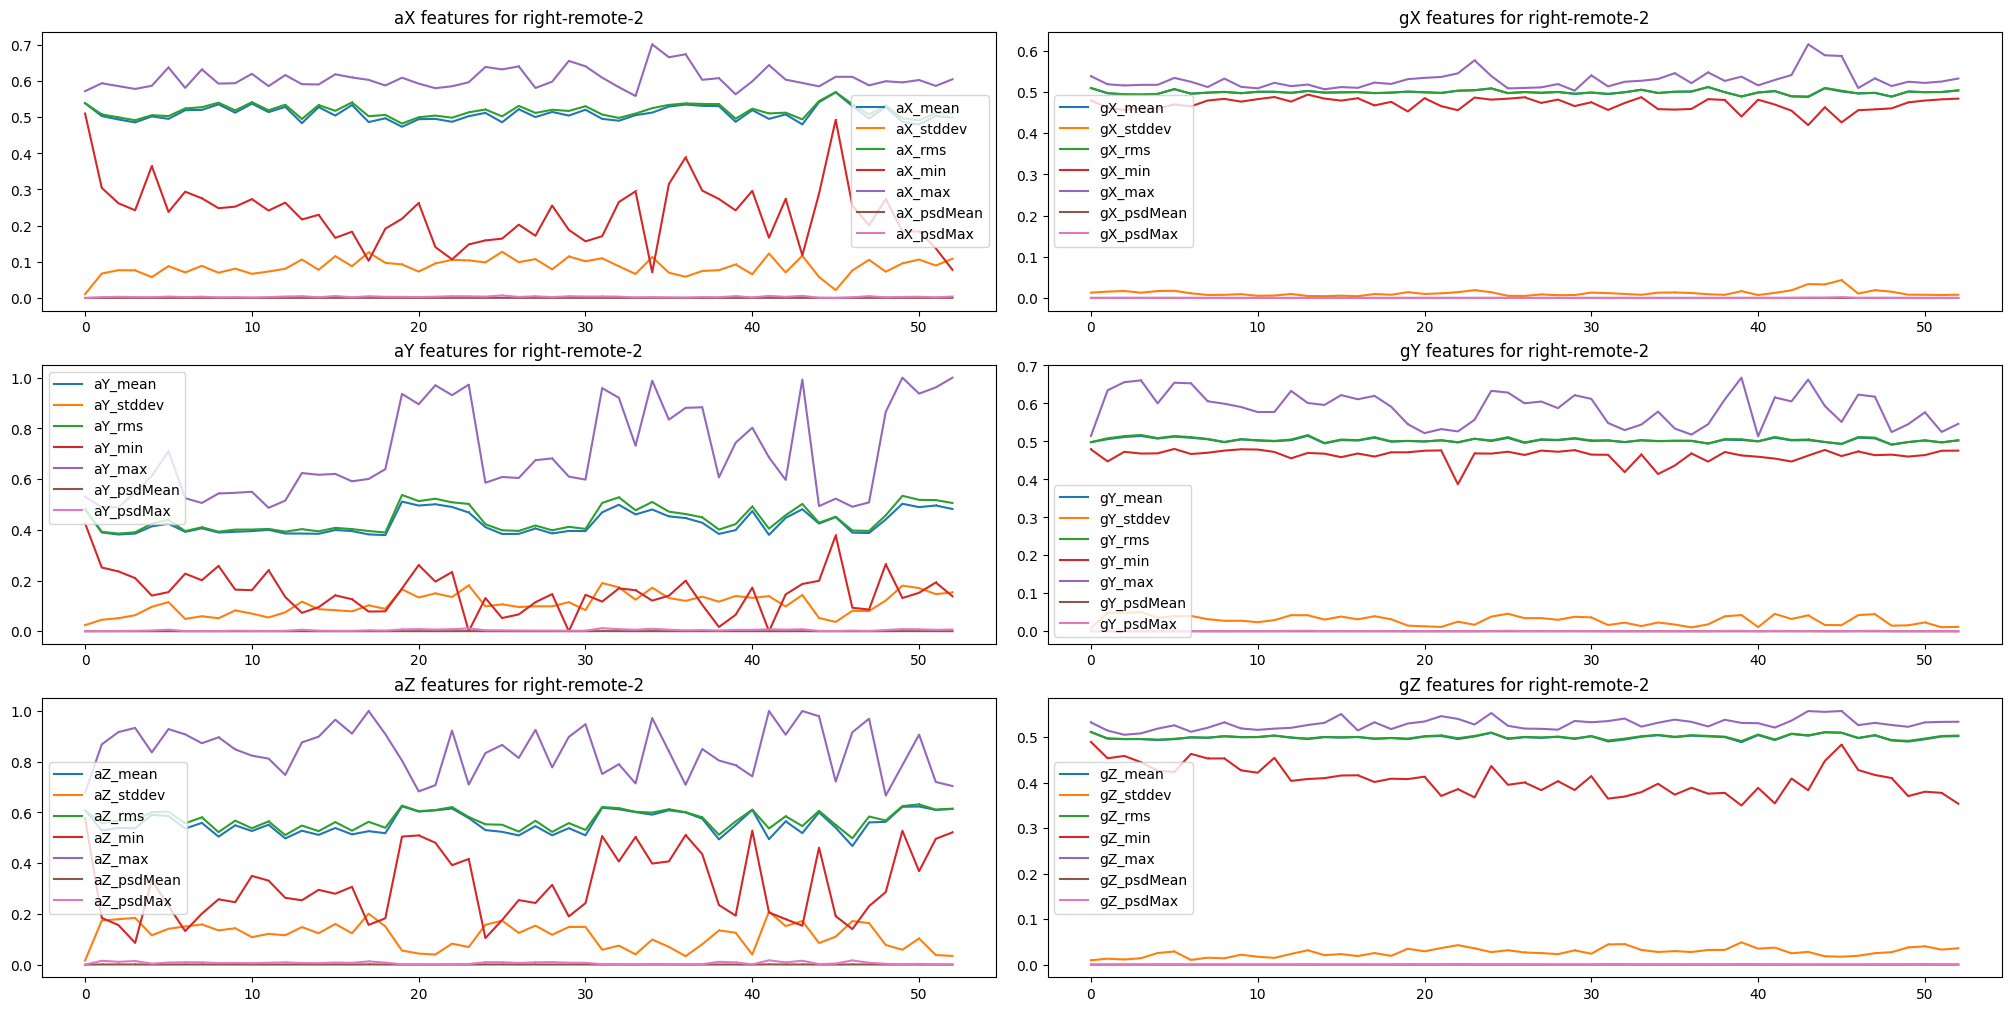

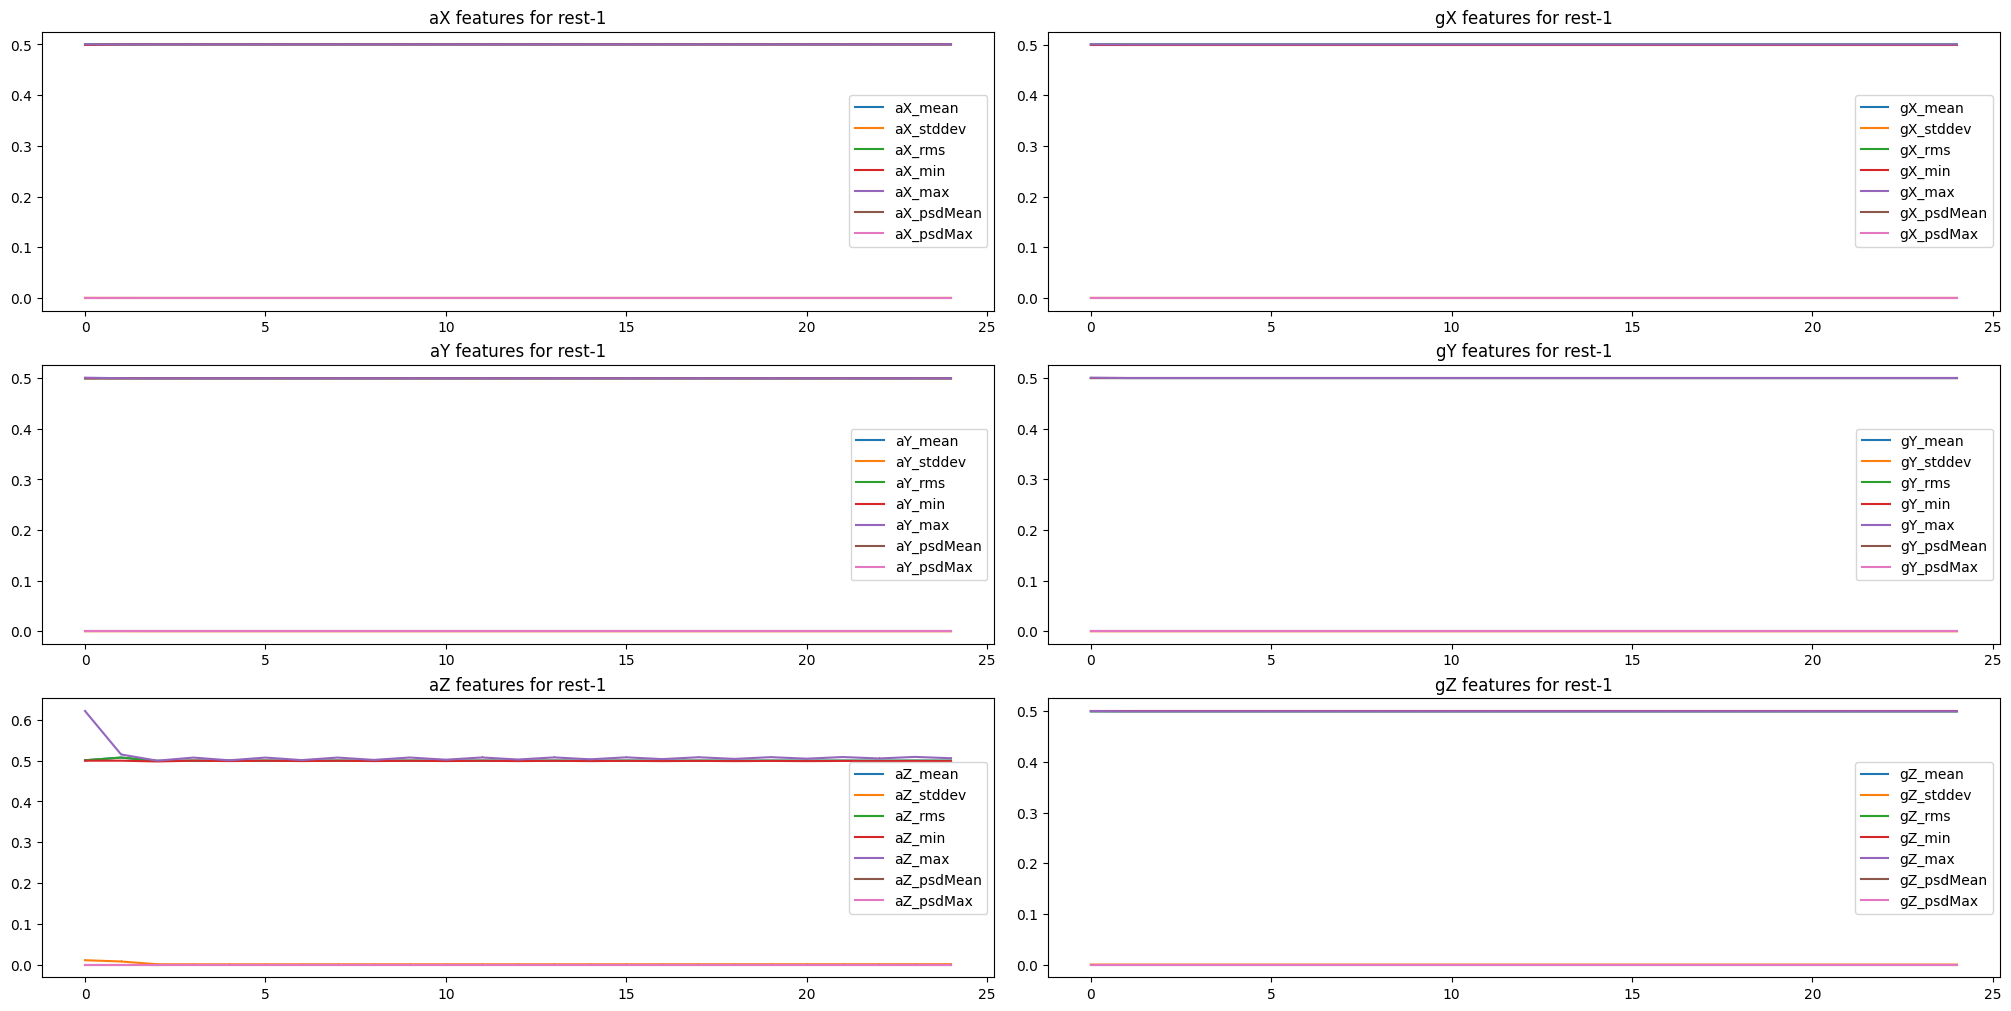

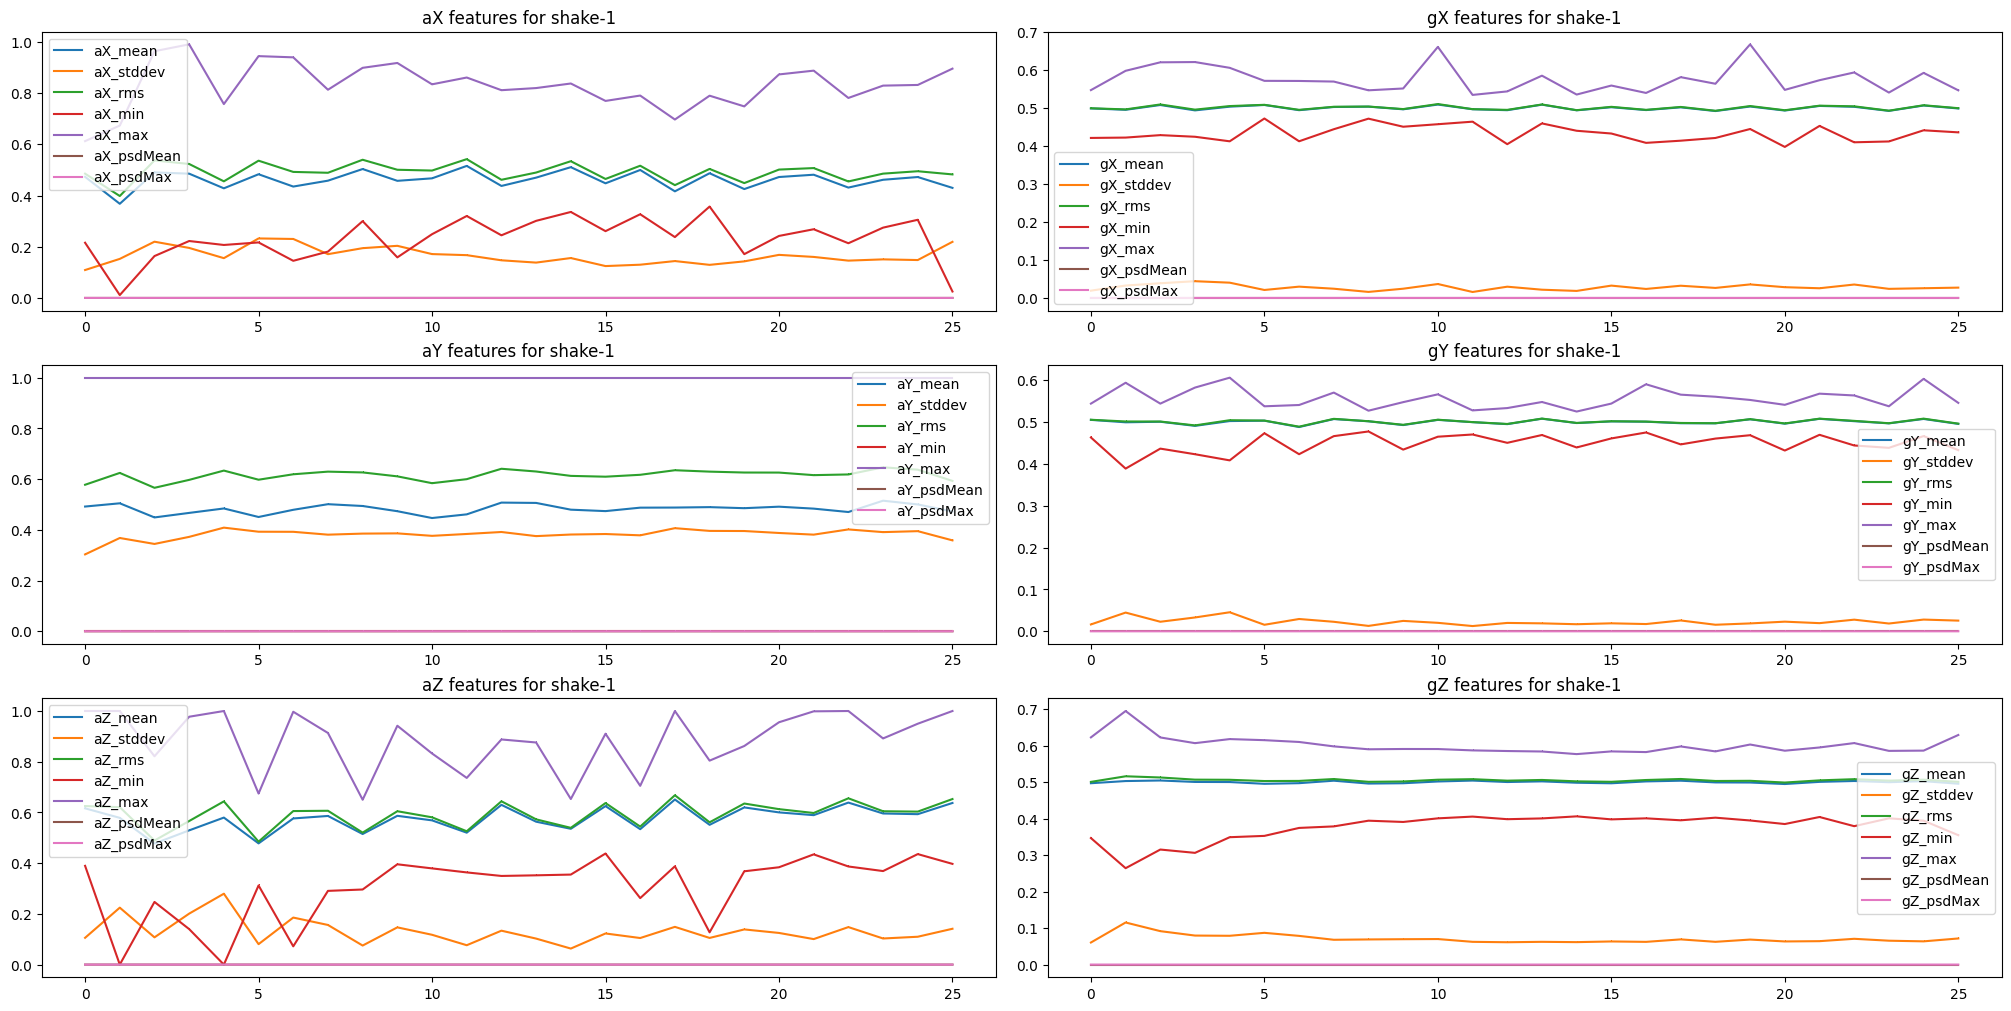

In [14]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# the list of gestures that data is available for
GESTURES = [
    "left-remote-2",
    "right-remote-2",
    "rest-1",
    "shake-1"
]

# Number of gestures we have
NUM_GESTURES = len(GESTURES) 

# Features
AXES = ['X', 'Y', 'Z']
VAL_PER_AXIS = ['a', 'g']
FEATURES_PER_VAL = ['mean', 'stddev', 'rms', 'min', 'max', 'psdMean', 'psdMax']


for filename in GESTURES :
  fig, ax = plt.subplots(len(AXES), len(VAL_PER_AXIS), layout='constrained')
  name = base_path + filename + ".csv"

  df = pd.read_csv(name)

  for axis in AXES:
    for val in VAL_PER_AXIS:
      # fig, ax = plt.subplots(2, 1, figsize=(20, 10), layout='constrained')
      col = VAL_PER_AXIS.index(val)
      row = AXES.index(axis)
      for feat in FEATURES_PER_VAL:
        dfCol = f"{val}{axis}_{feat}"
        # print(f"{row} {col}")
        ax[row,col].plot(df[dfCol], label=dfCol, linestyle='solid', marker=',')
      ax[row,col].set_title(f"{val}{axis} features for {filename}")
      ax[row,col].legend()
      
  plt.show()


# Extraction of features (this is done on the Arduino)
We created a function `extract_features` which extract the features in the "window" we are looking at. We grouped the temporal and frequential features goether in a list called `features` of size $7 \times 6 = 42$. Where 7 is the number of features (5 for temporal and 2 for frequential) and 6 for the number of axes : `aX,aY,aZ,gX,gY,gZ` where `a`represents the acceleration and `g`the gyroscope.
Some reminder of formulas we used for different features:  
- The PSD (_Power Spectral Density_) is used here to normalize the power of the signal concerning the size of the frequency bin. The formula is : $PSD(f) = \frac{|f|^2}{Nf_s}$ where $N$ is the length of the signal and $f_s$ is the sampling frequency. We used here 1000hz
- The RMS (Root Mean Squaered) : $RMS = \sqrt{\frac{1}{N} \sum_{i=0}^N x_i^2}$, to simplify in our implementation we used the square-root of the mean which is clearer for the reader.
## Why to run this part in the Arduino side?
We started to use different approaches to extract the features on the microcontroller (uC), but after we noticed that there was an error on how the features were extracted on the python side. Changed the way we extracted the features on the python, the inference was not working anymore. 
This move our attention to the way we were extracting the features on the microcontroller, adding the true extraction of the features, implementing also FFT and PSD, but also using this, we were not able to have a good inference on the microcontroller.
So we decided to extract the features on the uC and doing the training using the features extracted. This way we are sure that the features are extracted in the same way on both sides, and we are also sure that the inference is working on the microcontroller.

# Train Neural Network





In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
# SEED = 1563
# Use Timestamp as seed for more randomness
SEED = int(pd.Timestamp.now().timestamp())
np.random.seed(SEED)
tf.random.set_seed(SEED)

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

windows = []  #This will hold the raw data windows for each gesture recording

inputs = np.empty((0, len(VAL_PER_AXIS)* len(FEATURES_PER_VAL) * len(AXES)))  # Initialize as an empty array with 6 columns
outputs = np.empty((0, NUM_GESTURES))  # Initialize as an empty array with 6 columns

# read each csv file and push an input and output\

for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")
  df = pd.read_csv(base_path + gesture + ".csv")
  num_recordings = int(df.shape[0])
  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  # Create the input
  input = df.to_numpy()
  # Create the output
  output = [ONE_HOT_ENCODED_GESTURES[gesture_index]] * num_recordings

  inputs = np.concatenate((inputs, input), axis=0) if inputs.size else np.array(input)
  outputs = np.concatenate((outputs, output), axis=0) if outputs.size else np.array(output)


print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)

print("Data set parsing and preparation complete.")


TensorFlow version = 2.21.0

Processing index 0 for gesture 'left-remote-2'.
	There are 47 recordings of the left-remote-2 gesture.
Processing index 1 for gesture 'right-remote-2'.
	There are 53 recordings of the right-remote-2 gesture.
Processing index 2 for gesture 'rest-1'.
	There are 25 recordings of the rest-1 gesture.
Processing index 3 for gesture 'shake-1'.
	There are 26 recordings of the shake-1 gesture.
Input shape: (151, 42)
Output shape: (151, 4)
Data set parsing and preparation complete.


## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the Neural Network.
Here we consider a sample of `119`

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [16]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs) #60% of our datas are for the training here
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT) #40% of our datas are for the testing phase

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Training shape:", inputs_train.shape, outputs_train.shape)
print("Validation shape:", inputs_validate.shape, outputs_validate.shape)
print("Testing shape:", inputs_test.shape, outputs_test.shape)

print("Data set randomization and splitting complete.")

Training shape: (90, 42) (90, 4)
Validation shape: (31, 42) (31, 4)
Testing shape: (30, 42) (30, 4)
Data set randomization and splitting complete.


## Build & Train the Model

We Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.
Here

In [17]:
# Build the model and train it
model = tf.keras.Sequential()
print("number of inputs : ", inputs.shape[1])

# We add the input_shape to be more efficient for tensorflow here
# We define it with the number of inputs we computed above (6*7)
model.add(tf.keras.layers.Dense(15, activation='relu',input_shape=(inputs.shape[1],))) # relu is used for performance
model.add(tf.keras.layers.Dense(7, activation='relu'))
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')) # softmax is used, because we only expect one gesture to occur per input

# Loss : we use categorical_crossentropy adapted to classification with more than 2 classes
# Metric : accuracy (for the same reason)
# Optimizer : more modern, Adam (Adaptative Moment Estmiation), each weight has his own learning rate adaptative
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#For the batch_size we changed it by 8 because there is too much noise at 1
#so 8 seems to be a good compromise to have a fast convergence.
history = model.fit(inputs_train, outputs_train, epochs=300, batch_size=8, validation_data=(inputs_validate, outputs_validate))


number of inputs :  42
Epoch 1/300


/Users/titien/Documents/ZZ2/S8/LOW-POWER-EMBEDDED-SYSTEMS/intro-tinyml/python-venv/env-arduino-3_11/env-3.11-fixed/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3111 - loss: 1.3206 - val_accuracy: 0.3226 - val_loss: 1.3426
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.3101 - val_accuracy: 0.3226 - val_loss: 1.3354
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.3023 - val_accuracy: 0.3226 - val_loss: 1.3294
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.2956 - val_accuracy: 0.3226 - val_loss: 1.3249
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.2888 - val_accuracy: 0.3226 - val_loss: 1.3196
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.2823 - val_accuracy: 0.3226 - val_loss: 1.3149
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.2758 - val_accuracy: 0.3226 - val_loss: 1.3102
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3111 - loss: 1.2689 - val_accuracy: 0.3226 - val_loss: 1.3

## Verify

Graph the models performance vs validation.


### Graph the loss

Graph the loss to see when the model stops improving.

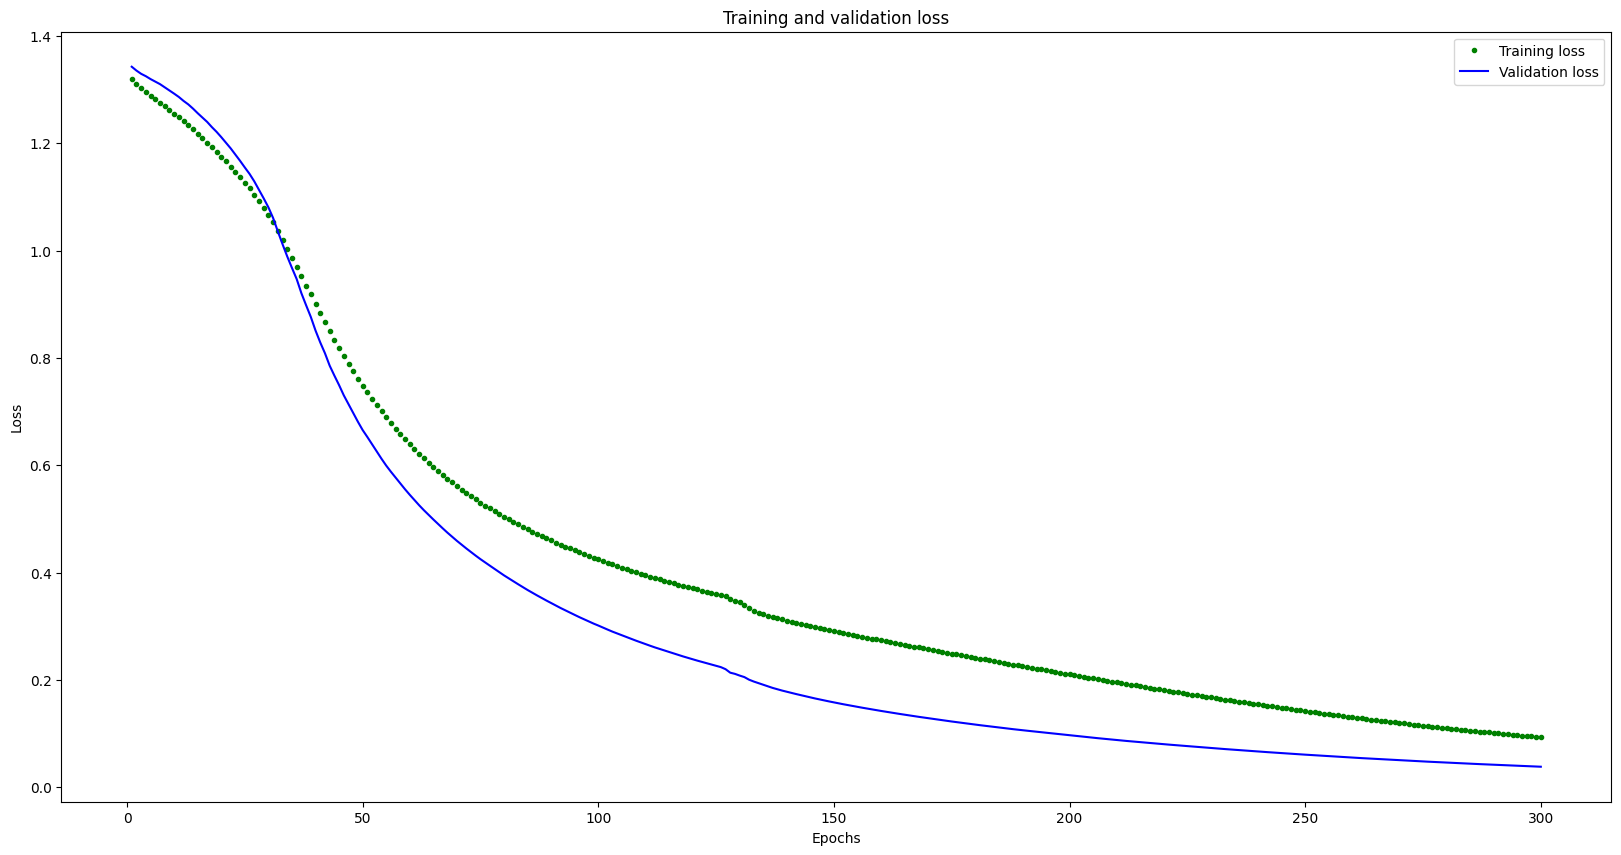

[20.0, 10.0]


In [18]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

### Graph the loss again, skipping a bit of the start

We'll graph the same data as the previous code cell, but start at index 100 so we can further zoom in once the model starts to converge.

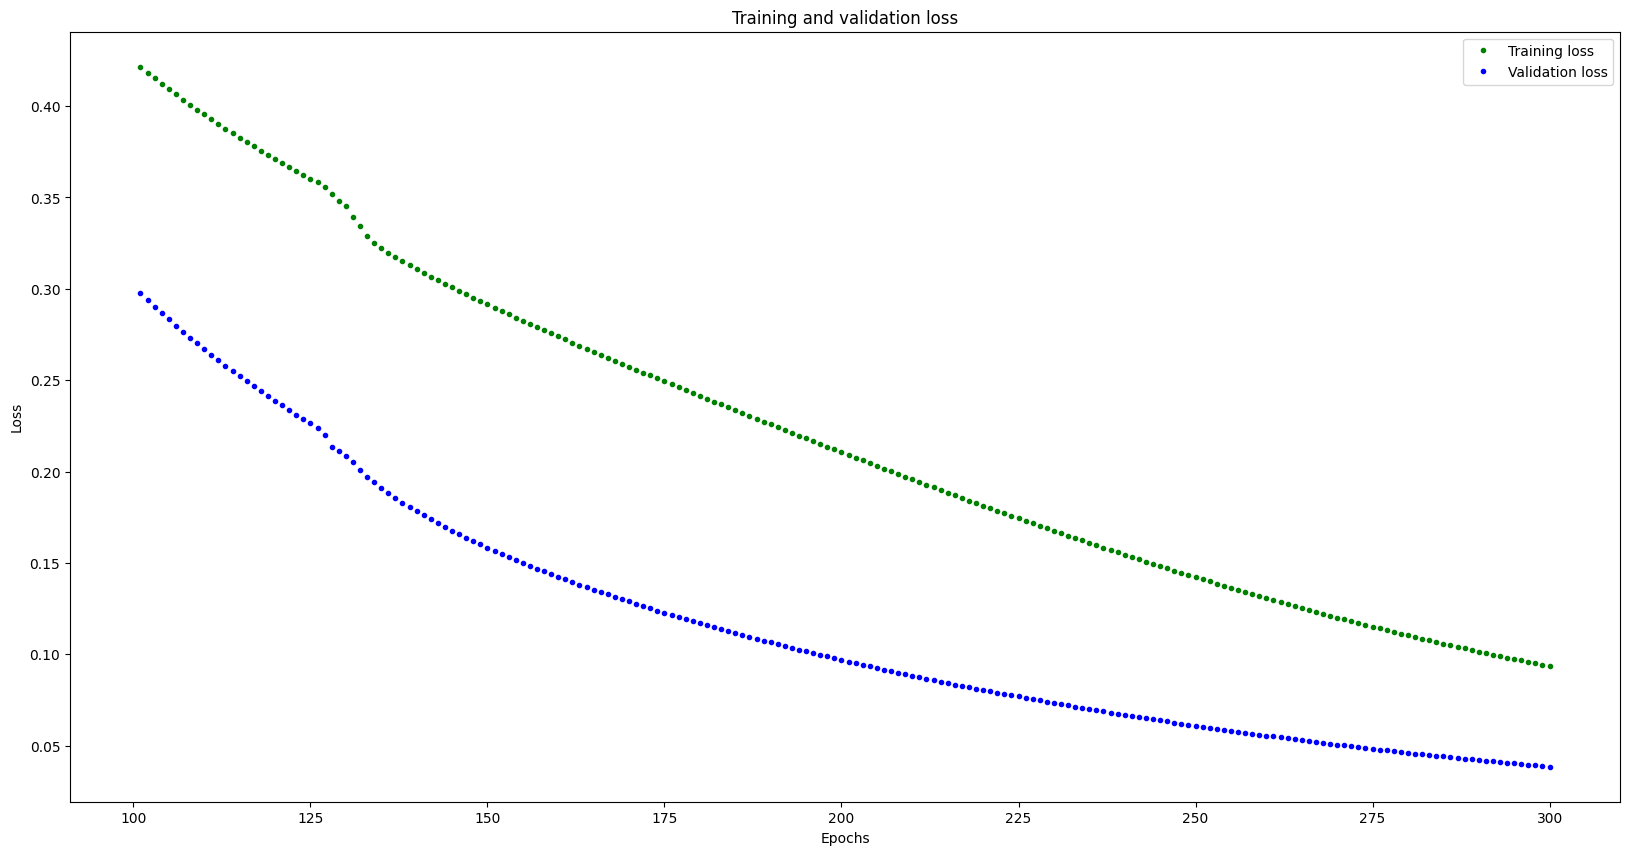

In [19]:
# graph the loss again skipping a bit of the start
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Run with Test Data
Put our test data into the model and plot the predictions


Test accuracy: 0.9667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9667 - loss: 0.1149
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


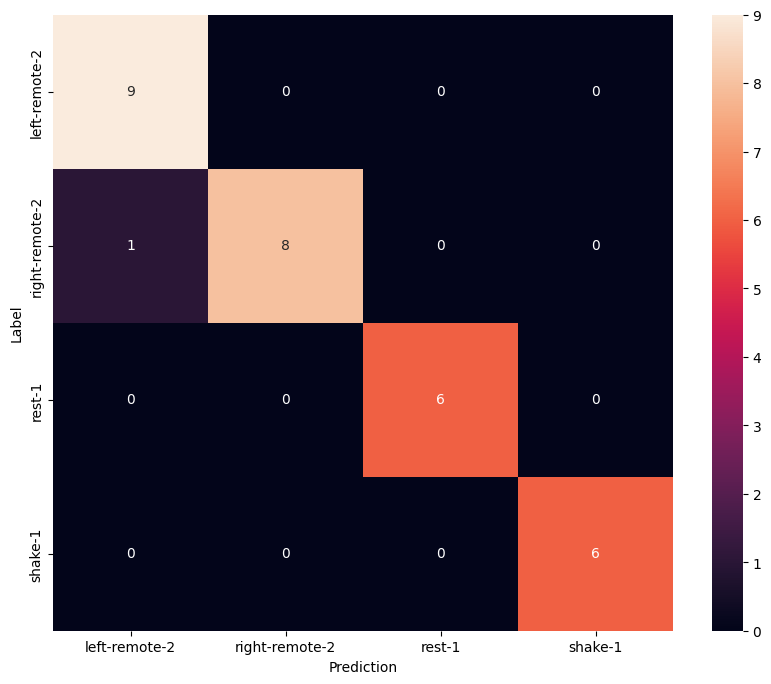

predicted classes =
 [0 3 0 3 0 0 1 2 0 1 3 1 2 3 2 1 2 0 1 0 2 0 1 1 2 3 0 0 1 3]
actual classes =
 [0 3 0 3 0 0 1 2 1 1 3 1 2 3 2 1 2 0 1 0 2 0 1 1 2 3 0 0 1 3]


In [20]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(inputs_test, outputs_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# use the model to predict the test inputs
predictions = model.predict(inputs_test)

# Convert to class indices
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(outputs_test, axis=1)

# # use the model to predict the test inputs
model.evaluate(inputs_test, outputs_test)
predictions = model.predict(inputs_test)

# # print the predictions and the expected 


# confusion matrix
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=GESTURES,
            yticklabels=GESTURES,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

# print the predictions and the expected ouputs
# print("predictions =\n", np.round(predictions, decimals=3))
# print("actual =\n", outputs_test)
print("predicted classes =\n", y_pred)
print("actual classes =\n", y_true)


# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [22]:
# Check if the output directory exists, if not create it
import os
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open(output_path + "gesture_model.tflite", "wb").write(tflite_model)

basic_model_size = os.path.getsize(output_path + "gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)

INFO:tensorflow:Assets written to: /var/folders/nh/lsvn3svx74ggdl2cxrbf1y_m0000gn/T/tmp6z46hkq8/assets


INFO:tensorflow:Assets written to: /var/folders/nh/lsvn3svx74ggdl2cxrbf1y_m0000gn/T/tmp6z46hkq8/assets


Saved artifact at '/var/folders/nh/lsvn3svx74ggdl2cxrbf1y_m0000gn/T/tmp6z46hkq8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  4781340432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4783175248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4783164496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4783165264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4783175056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4783176976: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 5392 bytes


W0000 00:00:1781910863.009129 1311077 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781910863.009137 1311077 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781910863.009203 1311077 reader.cc:83] Reading SavedModel from: /var/folders/nh/lsvn3svx74ggdl2cxrbf1y_m0000gn/T/tmp6z46hkq8
I0000 00:00:1781910863.009344 1311077 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781910863.009346 1311077 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/nh/lsvn3svx74ggdl2cxrbf1y_m0000gn/T/tmp6z46hkq8
I0000 00:00:1781910863.010429 1311077 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781910863.016796 1311077 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/nh/lsvn3svx74ggdl2cxrbf1y_m0000gn/T/tmp6z46hkq8
I0000 00:00:1781910863.018809 1311077 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 9607 microseconds.


## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [23]:
def convert_tflite_to_header(tflite_path, header_path):
  # Reading the TFLite model file as binary data
  with open(tflite_path, 'rb') as f:
    data = f.read()

  with open(header_path, 'w') as f:
    # Write the header guard and the declaration of the model array
    f.write("const unsigned char model[] = {\n")
    
    # Converting each byte to hexadecimal format (0x00)
    # We put 12 bytes per line to keep the file readable
    hex_lines = []
    for i in range(0, len(data), 12):
      chunk = data[i:i + 12]
      hex_chunk = ", ".join([f"0x{b:02x}" for b in chunk])
      hex_lines.append("  " + hex_chunk)
    
    # Join the lines with a comma and newline
    f.write(",\n".join(hex_lines))
    
    # Close the array
    f.write("\n};\n")

# Conversion
convert_tflite_to_header(output_path + "gesture_model.tflite", output_path + "model.h")

import os
model_h_size = os.path.getsize(output_path + "model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 33,286 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.


## Convert the test dataset to a C header file
The next cell creates a constant byte array that contains the test dataset.

In [24]:
# Export the test dataset to a C header file
def convert_test_dataset_to_header(inputs, outputs, header_path):
  with open(header_path, 'w') as f:
    f.write("#ifndef __TEST_DATA_H__\n")
    f.write("#define __TEST_DATA_H__\n\n")
    f.write("#include <stdint.h>\n\n")
    f.write(f"const uint16_t num_samples = {len(inputs)};\n")
    f.write(f"const uint16_t num_features = {inputs.shape[1]};\n")
    f.write(f"const uint16_t num_classes = {outputs.shape[1]};\n\n")
    
    # Write the input data
    f.write("const float test_inputs[][num_features] = {\n")
    for i in range(len(inputs)):
        input_line = ", ".join([f"{x:.6f}f" for x in inputs[i]])
        f.write(f"  {{{input_line}}},\n")
    f.write("};\n\n")
    
    # Write the output data
    f.write("const uint8_t test_outputs[][num_classes] = {\n")
    for i in range(len(outputs)):
        output_line = ", ".join([str(int(x)) for x in outputs[i]])
        f.write(f"  {{{output_line}}},\n")
    f.write("};\n")
    f.write("\n#endif // __TEST_DATA_H__\n")
    
# Conversion
convert_test_dataset_to_header(inputs_test, outputs_test, output_path + "test_data.h")